## Cell 1 — Kaggle Setup

In [1]:
import os, subprocess
from pathlib import Path

# ── Find AD/CN/MCI root ─────────────────────────────────────────────────────

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')

TARGET_CLASSES = {'AD', 'CN', 'MCI'}

def find_adni_root(search_roots):
    """
    Check at most 2 levels deep (root itself, then its direct children).
    This avoids picking up the tensor-cache directory
    (/kaggle/working/preprocessed_*/train/AD …) which is 3 levels deep.
    """
    for sr in search_roots:
        sr = Path(sr)
        if not sr.exists():
            continue
        try:
            subdirs = {d for d in os.listdir(sr) if os.path.isdir(sr / d)}
            if TARGET_CLASSES.issubset(subdirs):
                return str(sr)
        except PermissionError:
            pass
        try:
            for sub in sorted(os.listdir(sr)):
                sub_path = sr / sub
                if not sub_path.is_dir():
                    continue
                try:
                    subdirs = {d for d in os.listdir(sub_path) if (sub_path / d).is_dir()}
                    if TARGET_CLASSES.issubset(subdirs):
                        return str(sub_path)
                except PermissionError:
                    pass
        except PermissionError:
            pass
    return None

# --- Search /kaggle/input first (Kaggle dataset attached via "Add Data") ---
ADNI_DIR = find_adni_root(['/kaggle/input/datasets/faridaali202301940/adnidataset'])

# --- Then /kaggle/working (previous gdown download) ---
if ADNI_DIR is None:
    ADNI_DIR = find_adni_root([WORK_DIR])

# --- Download if still not found ---
if ADNI_DIR is None:
    ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'
    print('Dataset not found locally — downloading via gdown ...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)
    ADNI_DIR = find_adni_root([WORK_DIR])

if ADNI_DIR is None:
    raise RuntimeError(
        'Could not find a directory containing AD, CN, MCI subfolders.\n'
        'Options:\n'
        '  1. Add the Alzheimer dataset via Kaggle "Add Data" (fastest).\n'
        '  2. Set GDRIVE_FILE_ID to your own Google Drive zip.\n'
        '  3. Manually set ADNI_DIR below.'
    )

print(f'ADNI_DIR = {ADNI_DIR}')

for cls in sorted(TARGET_CLASSES):
    cls_path = os.path.join(ADNI_DIR, cls)
    n = sum(len(f) for _, _, f in os.walk(cls_path)) if os.path.isdir(cls_path) else 0
    print(f'  {cls}: ~{n} files')


ADNI_DIR = /kaggle/input/datasets/faridaali202301940/adnidataset/adni_nifti_preprocessed
  AD: ~1434 files
  CN: ~2341 files
  MCI: ~4737 files


## Cell 2 — Imports, Seed & Device

In [2]:

%pip install -q timm shap lime scikit-image joblib


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os, csv, random, json, shutil, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Cell 3 — Configuration

In [4]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = '/kaggle/working/preprocessed_convmixer_patientlevel'
CKPT_DIR   = '/kaggle/working/checkpoints_convmixer_patientlevel'
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
N_FOLDS      = 5
BATCH_SIZE   = 32
TEST_RATIO   = 0.15

# ── ConvMixer training budget (3 classes x 5 folds = 15 trainings) ─────────
NUM_EPOCHS   = 12     # trimmed from the original 30, same reasoning as the Hybrid notebook
PATIENCE     = 5
LR           = 1e-3
BACKBONE_LR_MULT = 0.1
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0

RF_TREES = 200

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d)) and d in ('AD', 'CN', 'MCI')
])
if not CLASS_NAMES:
    CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
print(f'Classes found: {CLASS_NAMES}')

Classes found: ['AD', 'CN', 'MCI']


In [5]:
print('Configuration loaded.')
print(f'  Image size : {IMAGE_SIZE}x{IMAGE_SIZE}  |  K-Folds: {N_FOLDS}  |  Batch: {BATCH_SIZE}')
print(f'  ConvMixer  : {NUM_EPOCHS} epochs (patience={PATIENCE})  |  RF trees: {RF_TREES}')

Configuration loaded.
  Image size : 224x224  |  K-Folds: 5  |  Batch: 32
  ConvMixer  : 12 epochs (patience=5)  |  RF trees: 200


## Cell 5 — Leakage Check & Clean Patient Map

In [6]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f'[WARNING] Missing class folder: {cls_dir}')
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f'Total unique patients: {len(patient_classes)}')

leakage_patients = {pid: c for pid, c in patient_classes.items() if len(c) > 1}
print(f"\n{'='*55}\n  LEAKAGE CHECK\n{'='*55}")
if leakage_patients:
    print(f'  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}')
    for pid, classes in sorted(leakage_patients.items()):
        print(f'    {pid}  ->  {sorted(classes)}')
else:
    print('  No patients in multiple classes. Dataset is clean.')

clean_patients = {pid: list(c)[0] for pid, c in patient_classes.items() if pid not in leakage_patients}
print(f'\n  Patients kept    : {len(clean_patients)}')
print(f'  Patients excluded: {len(leakage_patients)}')

Total unique patients: 320

  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


## Cell 6 — Stratified Hold-Out Test Set (15%)

In [7]:
class_patients = defaultdict(list)
for pid, cls in clean_patients.items(): class_patients[cls].append(pid)
for cls in CLASS_NAMES: random.shuffle(class_patients[cls])

test_patients, trainval_patients = [], []
print('='*60); print('  HOLD-OUT TEST SET (stratified)'); print('='*60)
for cls in CLASS_NAMES:
    pids = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test]); trainval_patients.extend(pids[n_test:])
    print(f'  {cls:<6}: {len(pids):>4} total | test={n_test} | trainval={len(pids)-n_test}')

assert not (set(test_patients) & set(trainval_patients)), 'Overlap!'
print(f'  Test patients: {len(test_patients)} | Train+Val: {len(trainval_patients)}')

test_entries = []
for pid in test_patients:
    cls = clean_patients[pid]; label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: test_entries.append((path, label, pid))
print(f'  Test slices: {len(test_entries)}')

  HOLD-OUT TEST SET (stratified)
  AD    :   54 total | test=8 | trainval=46
  CN    :   88 total | test=13 | trainval=75
  MCI   :  178 total | test=26 | trainval=152
  Test patients: 47 | Train+Val: 273
  Test slices: 1261


## Cell 7 — Preprocess & Cache All Slices (224x224)

In [8]:
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]: all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc='Saving'):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f'_dup{fname_counts[key]}' if fname_counts[key] > 1 else ''
        out_path = os.path.join(out_dir, f'{key}{suffix}.pt')
        if not os.path.exists(out_path):
            img    = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = (transforms.ToTensor()(img) * 255).byte()
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc='Preprocessing')
print(f'Done. {len(all_entries)} slices cached.')

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir): continue
    for fname in os.listdir(cls_dir):
        if fname.endswith('.pt'): pt_lookup[fname[:-3]] = os.path.join(cls_dir, fname)
print(f'pt_lookup: {len(pt_lookup)} entries')

Preprocessing: 100%|██████████| 8512/8512 [01:37<00:00, 87.64it/s] 

Done. 8512 slices cached.
pt_lookup: 8512 entries


## Cell 8 — Dataset Class & Augmentation

In [9]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=(0.8, 1.2), contrast=(0.9, 1.1)),
])

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.augment = augment; self.samples = []
        for path, label, pid in entries:
            base = os.path.splitext(os.path.basename(path))[0]
            key  = f'{pid}_{base}'.replace('/', '_').replace('\\', '_')
            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                for dup in range(2, 50):
                    dk = f'{key}_dup{dup}'
                    if dk in pt_lookup: self.samples.append((pt_lookup[dk], label, pid)); break

    def __len__(self):  return len(self.samples)
    def get_labels(self): return [s[1] for s in self.samples]

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        t = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment: t = train_augment(t)
        return normalize(t), label, pid

print('SliceDataset defined.')

SliceDataset defined.


## Cell 9 — ConvMixer Architecture (unchanged)
`timm`'s `convmixer_768_32`, pretrained, plus a small classifier head. This
replaces DAD-Net's own from-scratch CNN at the equivalent point in the
notebook, kept as `build_dad_net` for call-site parity.


In [10]:
class ConvMixerWrapper(nn.Module):
    """CAD-ALZ paper: ConvMixer pretrained backbone + custom classifier head."""
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model('convmixer_768_32', pretrained=True, num_classes=0)
        self.feat_dim = 768
        self.drop = nn.Dropout(p=dropout)
        self.head = nn.Linear(self.feat_dim, num_classes)

    def get_blocks(self):
        return list(self.backbone.blocks.children())

    def extract_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.head(self.drop(self.extract_features(x)))

def build_dad_net(num_classes: int):
    return ConvMixerWrapper(num_classes=num_classes)

print('ConvMixer architecture defined.')

ConvMixer architecture defined.


## Cell 10 — Training Utilities
`run_epoch` matches DAD-Net's version (single-phase training — ConvMixer,
like DAD-Net's own CNN, trains end-to-end without a freeze/unfreeze split,
unlike the Hybrid notebook's pretrained-backbone case). The extra piece
DAD-Net doesn't need is `extract_features_and_fit_rf` / `rf_predict_proba`,
since the actual classifier here is a Random Forest sitting on top of the
ConvMixer features, not the ConvMixer's own softmax head.


In [11]:
def run_epoch(loader, model, criterion, optimizer=None, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels, _pids in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if torch.isnan(loss):
                continue
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)
    return total_loss / total, correct / total

def train_convmixer(model, train_loader, val_loader, criterion, ckpt_path, name):
    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': LR * BACKBONE_LR_MULT},
        {'params': model.head.parameters(),     'lr': LR},
        {'params': model.drop.parameters(),     'lr': LR},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, patience_ctr = 0.0, 0

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, desc=f'{name} ep{epoch} [train]')
        vl_loss, vl_acc = run_epoch(val_loader, model, criterion, desc=f'{name} ep{epoch} [val]')
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
        scheduler.step(vl_acc)
        print(f'  Ep {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.1f}% | '
              f'val loss={vl_loss:.4f} acc={vl_acc*100:.1f}%')
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc; torch.save(model.state_dict(), ckpt_path); patience_ctr = 0
            print(f'    * Best val_acc={best_val_acc*100:.2f}% -- saved.')
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'    Early stopping at epoch {epoch}.'); break

    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.eval()
    return history, best_val_acc

def extract_features(model, loader):
    """Returns (features [N, 768], labels [N], pids [N])."""
    model.eval()
    feats, lbls, pids_out = [], [], []
    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc='Extracting features', leave=False):
            images = images.to(device, non_blocking=True)
            f = model.extract_features(images)
            feats.append(f.cpu().float().numpy())
            lbls.extend(labels.numpy().tolist())
            pids_out.extend(list(pids))
    return np.vstack(feats), np.array(lbls), pids_out

def patient_level_eval_rf(probs, labels, pids, num_classes=2):
    """Aggregate RF predict_proba slice-level output per patient (mean)."""
    patient_probs  = defaultdict(lambda: np.zeros(num_classes))
    patient_labels = {}
    for prob, lbl, pid in zip(probs, labels, pids):
        patient_probs[pid] += prob; patient_labels[pid] = int(lbl)
    all_true, all_pred = [], []
    for pid, ps in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(ps)))
    return float(np.mean(np.array(all_true) == np.array(all_pred))), all_true, all_pred

print('Training utilities defined.')

Training utilities defined.


## Cell 11 — K-Fold Cross-Validation: 1-vs-All (ConvMixer + RF per fold)
Same fold-splitting and imbalance handling as DAD-Net's Cell 11
(patient-grouped folds, `WeightedRandomSampler`). Each fold trains a fresh
ConvMixer, then extracts its 768-D features and fits a fresh Random Forest
on them — the RF is the actual classifier being cross-validated, per the
original notebook's design.


In [12]:
trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)
for cls in CLASS_NAMES: random.shuffle(trainval_by_class[cls])

fold_results       = {cls: [] for cls in CLASS_NAMES}   # patient-level val acc per fold
all_fold_models    = {cls: [] for cls in CLASS_NAMES}   # ConvMixer models, kept on CPU between uses
all_fold_rfs       = {cls: [] for cls in CLASS_NAMES}   # matching RandomForestClassifier per fold
all_fold_ckpts     = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f'\n{"="*68}')
    print(f'  {pos_name} vs REST  --  {N_FOLDS}-Fold CV  (ConvMixer + RF)')
    print(f'{"="*68}')

    class_folds = {cls: [trainval_by_class[cls][i::N_FOLDS] for i in range(N_FOLDS)]
                   for cls in CLASS_NAMES}

    for fold_idx in range(N_FOLDS):
        print(f'\n  --- Fold {fold_idx+1}/{N_FOLDS} ---')
        val_pids, train_pids = [], []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                (val_pids if k == fold_idx else train_pids).extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                c = clean_patients[pid]; l = CLASS_NAMES.index(c)
                for path in patient_slices[(pid, c)]: out.append((path, l, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in entries]

        train_bin = binarize(expand(train_pids))
        val_bin   = binarize(expand(val_pids))
        train_ds  = SliceDataset(train_bin, augment=True)
        val_ds    = SliceDataset(val_bin,   augment=False)
        val_ds_noaug_for_rf = val_ds   # no augmentation is used for val/feature-extraction anyway

        if len(train_ds) == 0:
            raise RuntimeError(f'Fold {fold_idx+1} ({pos_name}): train_ds empty. Re-run Cell 7.')

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f'  Train -- {pos_name}: {pos_count} | REST: {neg_count} | Val patients: {len(val_pids)}')

        cls_counts = Counter(train_ds.get_labels())
        weights    = [1.0 / cls_counts[l] for l in train_ds.get_labels()]
        sampler    = WeightedRandomSampler(weights, len(weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=2, pin_memory=(device.type == 'cuda'), persistent_workers=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=2, pin_memory=(device.type == 'cuda'), persistent_workers=True)

        criterion = nn.CrossEntropyLoss()
        model = build_dad_net(num_classes=2).to(device)
        ckpt_path = os.path.join(CKPT_DIR, f'convmixer_fold{fold_idx+1}_{pos_name}_vs_REST.pt')

        history, _ = train_convmixer(model, train_loader, val_loader, criterion, ckpt_path,
                                     f'{pos_name} fold{fold_idx+1}')

        # -- Feature extraction + Random Forest (the actual classifier) --
        feat_train_loader = DataLoader(SliceDataset(train_bin, augment=False), batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=2, pin_memory=(device.type == 'cuda'))
        X_train, y_train, _ = extract_features(model, feat_train_loader)
        X_val,   y_val, val_pids_flat = extract_features(model, val_loader)

        rf = RandomForestClassifier(n_estimators=RF_TREES, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
        rf.fit(X_train, y_train)

        val_probs = rf.predict_proba(X_val)
        pat_acc, _, _ = patient_level_eval_rf(val_probs, y_val, val_pids_flat, num_classes=2)
        print(f'  Fold {fold_idx+1} -- Patient-level val acc (ConvMixer+RF): {pat_acc*100:.2f}%')

        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        model.to('cpu').eval(); all_fold_models[pos_name].append(model)
        all_fold_rfs[pos_name].append(rf)

        del train_ds, val_ds, X_train, X_val
        torch.cuda.empty_cache()

    print(f'\n  {pos_name} vs REST -- CV: '
          f'{np.mean(fold_results[pos_name])*100:.2f}% +/- {np.std(fold_results[pos_name])*100:.2f}%')

print('\nAll folds done.')


  AD vs REST  --  5-Fold CV  (ConvMixer + RF)

  --- Fold 1/5 ---
  Train -- AD: 950 | REST: 4808 | Val patients: 56


model.safetensors:   0%|          | 0.00/84.9M [00:00<?, ?B/s]

  Ep 01 | train loss=0.5635 acc=69.6% | val loss=0.7516 acc=61.4%
    * Best val_acc=61.42% -- saved.


  Ep 02 | train loss=0.3322 acc=85.9% | val loss=0.6533 acc=76.1%
    * Best val_acc=76.09% -- saved.


  Ep 03 | train loss=0.1896 acc=92.2% | val loss=0.8957 acc=76.2%
    * Best val_acc=76.22% -- saved.


...

  Ep 04 | train loss=0.4131 acc=81.3% | val loss=1.0874 acc=53.2%


  Ep 05 | train loss=0.2977 acc=87.7% | val loss=1.4111 acc=53.8%


  Ep 06 | train loss=0.2200 acc=90.9% | val loss=1.6182 acc=52.1%


  Ep 07 | train loss=0.1561 acc=93.9% | val loss=1.9430 acc=52.8%
    Early stopping at epoch 7.


  Fold 5 -- Patient-level val acc (ConvMixer+RF): 51.85%

  MCI vs REST -- CV: 53.88% +/- 4.77%

All folds done.


## Cell 12 — Weighted Ensemble Test Evaluation (Binary, Patient-Level)
Each fold's ConvMixer produces test-set features, that fold's RF turns them
into a probability, and the five folds are combined with the same
val-accuracy weighting used everywhere else.


  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (ConvMixer + RF)

  AD vs REST
    Fold 1: val_acc=80.36%  weight=0.1967
    Fold 2: val_acc=80.00%  weight=0.1958
    Fold 3: val_acc=81.48%  weight=0.1995
    Fold 4: val_acc=85.19%  weight=0.2085
    Fold 5: val_acc=81.48%  weight=0.1995



  Test Acc (AD vs REST): 85.11%  [47 patients]
              precision    recall  f1-score   support

        REST       0.86      0.97      0.92        39
          AD       0.67      0.25      0.36         8

    accuracy                           0.85        47
   macro avg       0.77      0.61      0.64        47
weighted avg       0.83      0.85      0.82        47



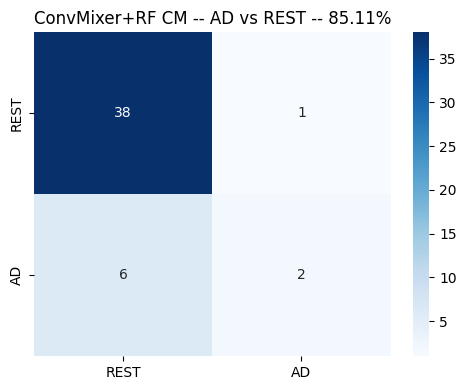


  CN vs REST
    Fold 1: val_acc=69.64%  weight=0.1872
    Fold 2: val_acc=74.55%  weight=0.2004
    Fold 3: val_acc=75.93%  weight=0.2041
    Fold 4: val_acc=75.93%  weight=0.2041
    Fold 5: val_acc=75.93%  weight=0.2041



  Test Acc (CN vs REST): 76.60%  [47 patients]
              precision    recall  f1-score   support

        REST       0.77      0.97      0.86        34
          CN       0.75      0.23      0.35        13

    accuracy                           0.77        47
   macro avg       0.76      0.60      0.61        47
weighted avg       0.76      0.77      0.72        47



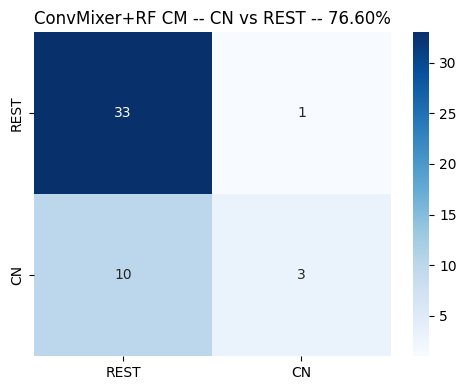


  MCI vs REST
    Fold 1: val_acc=51.79%  weight=0.1922
    Fold 2: val_acc=49.09%  weight=0.1822
    Fold 3: val_acc=62.96%  weight=0.2337
    Fold 4: val_acc=53.70%  weight=0.1993
    Fold 5: val_acc=51.85%  weight=0.1925



  Test Acc (MCI vs REST): 59.57%  [47 patients]
              precision    recall  f1-score   support

        REST       0.55      0.52      0.54        21
         MCI       0.63      0.65      0.64        26

    accuracy                           0.60        47
   macro avg       0.59      0.59      0.59        47
weighted avg       0.59      0.60      0.59        47



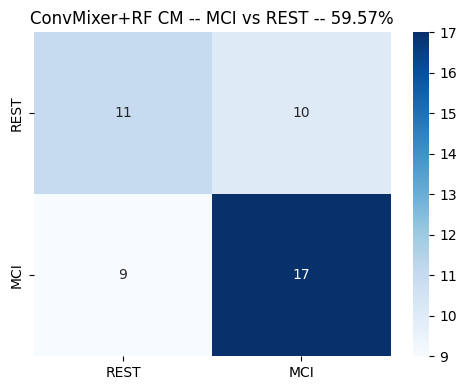

In [13]:
final_results = {}
print('='*68); print('  WEIGHTED ENSEMBLE -- HOLD-OUT TEST (ConvMixer + RF)'); print('='*68)

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ['REST', pos_name]
    test_bin     = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds      = SliceDataset(test_bin, augment=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=(device.type == 'cuda'))

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    print(f'\n  {pos_name} vs REST')
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f'    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}')

    fold_models = all_fold_models[pos_name]
    fold_rfs    = all_fold_rfs[pos_name]

    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    for fm, rf, w in zip(fold_models, fold_rfs, fold_weights):
        fm.to(device).eval()
        X_test, y_test, pids_test = extract_features(fm, test_loader)
        probs = rf.predict_proba(X_test)
        for prob, lbl, pid in zip(probs, y_test, pids_test):
            patient_probs[pid] += w * prob
            patient_labels[pid] = int(lbl)
        fm.to('cpu')

    all_true, all_pred = [], []
    for pid, wp in patient_probs.items():
        all_true.append(patient_labels[pid]); all_pred.append(int(np.argmax(wp)))

    pat_acc = float(np.mean(np.array(all_true) == np.array(all_pred)))
    print(f'\n  Test Acc ({pos_name} vs REST): {pat_acc*100:.2f}%  [{len(patient_probs)} patients]')
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm_mat = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=binary_names, yticklabels=binary_names)
    plt.title(f'ConvMixer+RF CM -- {pos_name} vs REST -- {pat_acc*100:.2f}%')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'cm_{pos_name}_vs_REST.png'), dpi=150); plt.show()

    final_results[pos_name] = {
        'patient_test_acc': pat_acc,
        'cv_mean_acc': float(np.mean(fold_accs)),
        'cv_std_acc':  float(np.std(fold_accs)),
        'fold_weights': fold_weights.tolist(),
    }
    torch.cuda.empty_cache()

## Cell 13 — OVA Multi-Class Prediction on Hold-Out Test Set

  OVA MULTI-CLASS -- HOLD-OUT TEST (ConvMixer + RF)
  Accuracy: 63.83%  [47 patients]
              precision    recall  f1-score   support

          AD       0.75      0.38      0.50         8
          CN       0.67      0.31      0.42        13
         MCI       0.62      0.88      0.73        26

    accuracy                           0.64        47
   macro avg       0.68      0.52      0.55        47
weighted avg       0.66      0.64      0.61        47



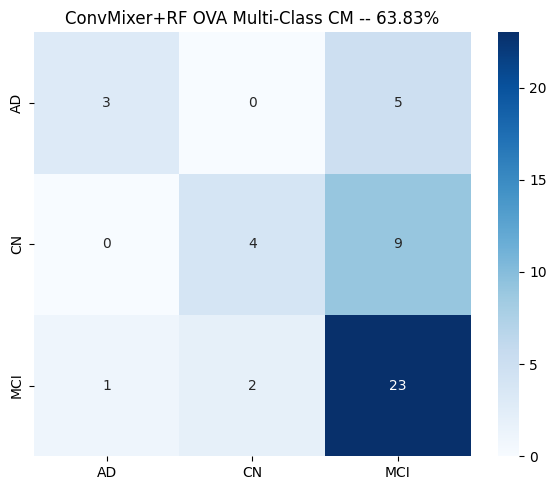

In [14]:
full_test_ds     = SliceDataset(test_entries, augment=False)
full_test_loader = DataLoader(full_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=(device.type == 'cuda'))

ova_probs  = defaultdict(lambda: {c: 0.0 for c in CLASS_NAMES})
ova_labels = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()
    fold_models  = all_fold_models[pos_name]
    fold_rfs     = all_fold_rfs[pos_name]

    for fm, rf, w in zip(fold_models, fold_rfs, fold_weights):
        fm.to(device).eval()
        X_full, y_full, pids_full = extract_features(fm, full_test_loader)
        probs = rf.predict_proba(X_full)
        for prob, lbl, pid in zip(probs, y_full, pids_full):
            ova_probs[pid][pos_name] += float(w * prob[1])
            ova_labels[pid] = int(lbl)
        fm.to('cpu')
    torch.cuda.empty_cache()

ova_true, ova_pred = [], []
for pid, conf in ova_probs.items():
    ova_pred.append(CLASS_NAMES.index(max(conf, key=conf.get)))
    ova_true.append(ova_labels[pid])

ova_acc = float(np.mean(np.array(ova_true) == np.array(ova_pred)))
print('='*68); print('  OVA MULTI-CLASS -- HOLD-OUT TEST (ConvMixer + RF)'); print('='*68)
print(f'  Accuracy: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print(classification_report(ova_true, ova_pred, target_names=CLASS_NAMES))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(ova_true, ova_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'ConvMixer+RF OVA Multi-Class CM -- {ova_acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_ova_multiclass.png'), dpi=150); plt.show()

Combined 3-Class Accuracy (argmax over OvA scores): 36.17%
              precision    recall  f1-score   support

          AD       0.23      0.75      0.35         8
          CN       0.43      0.23      0.30        13
         MCI       0.57      0.31      0.40        26

    accuracy                           0.36        47
   macro avg       0.41      0.43      0.35        47
weighted avg       0.47      0.36      0.36        47

Patients positive (score>0.5) on more than one OvA axis: 1 / 47


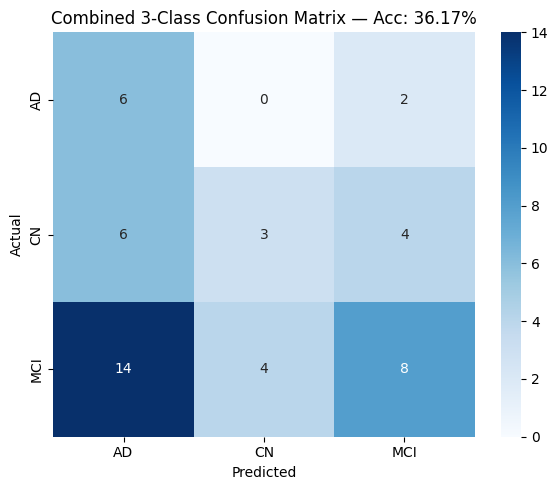

Saved per-patient predictions to /kaggle/working/checkpoints_convmixer_patientlevel/per_patient_resnet50_combined_predictions.csv


In [15]:
patient_class_scores = defaultdict(lambda: np.zeros(len(CLASS_NAMES)))
patient_true_label   = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    test_bin = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()

    fold_models_list = all_fold_models[pos_name]
    for m in fold_models_list:
        m.to(device)
        m.eval()

    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader, desc=f"{pos_name} (combined)", leave=False):
            images = images.to(device, non_blocking=True)
            batch_wp = np.zeros((images.size(0), 2))
            for fm, w in zip(fold_models_list, fold_weights):
                with torch.amp.autocast(device_type="cuda"):
                    logits = fm(images)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                batch_wp += w * probs
            for wp, pid in zip(batch_wp, pids):
                patient_class_scores[pid][pos_class_idx] += wp[1]  # prob of "positive"

    for m in fold_models_list:
        m.to("cpu")
    torch.cuda.empty_cache()

# slice count and true label per patient (same across all three passes)
slice_counts_per_patient = defaultdict(int)
for _, label, pid in test_entries:
    slice_counts_per_patient[pid] += 1
    patient_true_label[pid] = label

all_true, all_pred, pid_list = [], [], []
for pid, scores in patient_class_scores.items():
    avg_scores = scores / slice_counts_per_patient[pid]
    pred_label = int(np.argmax(avg_scores))
    all_true.append(patient_true_label[pid])
    all_pred.append(pred_label)
    pid_list.append(pid)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

combined_acc = np.mean(all_true == all_pred)
print(f"Combined 3-Class Accuracy (argmax over OvA scores): {combined_acc*100:.2f}%")
print(classification_report(all_true, all_pred, target_names=CLASS_NAMES))

# how many patients scored "positive" (>0.5) on more than one axis
multi_positive = 0
for pid, scores in patient_class_scores.items():
    avg_scores = scores / slice_counts_per_patient[pid]
    if np.sum(avg_scores > 0.5) > 1:
        multi_positive += 1
print(f"Patients positive (score>0.5) on more than one OvA axis: {multi_positive} / {len(patient_class_scores)}")

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Combined 3-Class Confusion Matrix — Acc: {combined_acc*100:.2f}%")
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_combined_3class.png"), dpi=150)
plt.show()

# save per-patient scores for the paper's supplementary material
import csv
csv_path = os.path.join(CKPT_DIR, "per_patient_resnet50_combined_predictions.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["patient_id", "true_label", "pred_label"] + [f"score_{c}" for c in CLASS_NAMES])
    for pid in pid_list:
        scores = patient_class_scores[pid] / slice_counts_per_patient[pid]
        writer.writerow([pid, CLASS_NAMES[patient_true_label[pid]],
                          CLASS_NAMES[int(np.argmax(scores))]] + list(scores))
print(f"Saved per-patient predictions to {csv_path}")

## Cell 14 — Final Summary & Export

  FINAL SUMMARY -- ConvMixer + RF (Weighted Ensemble, 1-vs-All)
  Class    CV Acc (mean+/-std)        Ensemble Test Acc
  ------------------------------------------------------------
  AD       81.70% +/- 1.84%           85.11%
  CN       74.39% +/- 2.43%           76.60%
  MCI      53.88% +/- 4.77%           59.57%

  OVA Multi-Class Test Acc: 63.83%  [47 patients]


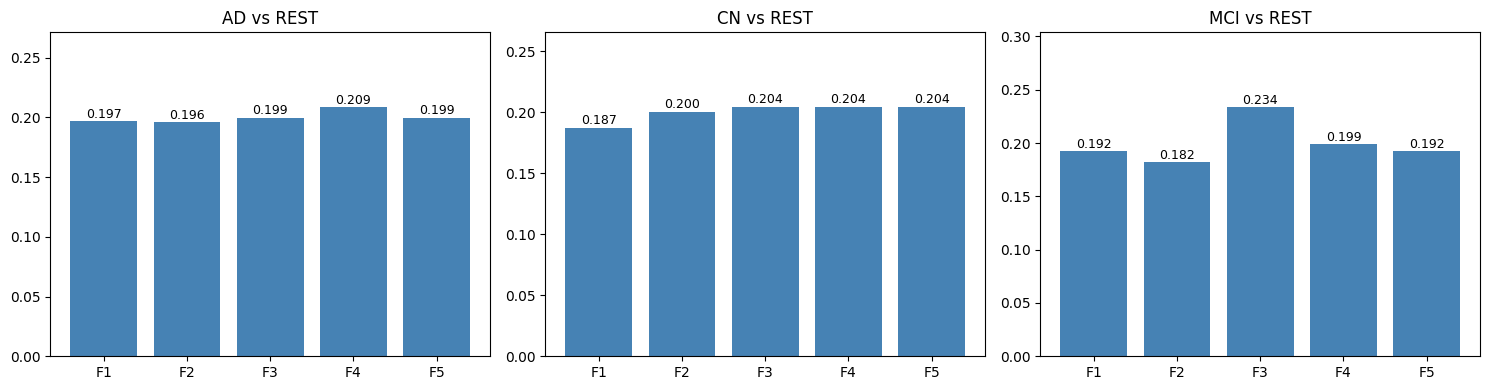

Results saved -> /kaggle/working/checkpoints_convmixer_patientlevel/results_convmixer_rf_patientlevel.csv
Done!


In [16]:
print('='*72)
print('  FINAL SUMMARY -- ConvMixer + RF (Weighted Ensemble, 1-vs-All)')
print('='*72)
print(f'  {"Class":<8} {"CV Acc (mean+/-std)":<26} {"Ensemble Test Acc"}')
print(f'  {"-"*60}')
for cls, res in final_results.items():
    cvs = f'{res["cv_mean_acc"]*100:.2f}% +/- {res["cv_std_acc"]*100:.2f}%'
    t   = f'{res["patient_test_acc"]*100:.2f}%'
    print(f'  {cls:<8} {cvs:<26} {t}')
print(f'\n  OVA Multi-Class Test Acc: {ova_acc*100:.2f}%  [{len(ova_true)} patients]')
print('='*72)

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(5*len(CLASS_NAMES), 4))
for ax, cls in zip(axes, CLASS_NAMES):
    wts = final_results[cls]['fold_weights']
    ax.bar([f'F{i+1}' for i in range(len(wts))], wts, color='steelblue')
    ax.set_title(f'{cls} vs REST'); ax.set_ylim(0, max(wts)*1.3)
    for i, w in enumerate(wts): ax.text(i, w+0.003, f'{w:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'fold_weights.png'), dpi=120); plt.show()

csv_path = os.path.join(CKPT_DIR, 'results_convmixer_rf_patientlevel.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'class','cv_mean_acc_%','cv_std_%','ensemble_test_acc_%','fold_weights','n_folds'])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({'class': cls,
                         'cv_mean_acc_%':       round(res['cv_mean_acc']*100, 2),
                         'cv_std_%':            round(res['cv_std_acc']*100, 2),
                         'ensemble_test_acc_%': round(res['patient_test_acc']*100, 2),
                         'fold_weights':        str([round(w,4) for w in res['fold_weights']]),
                         'n_folds': N_FOLDS})
    writer.writerow({'class': 'OVA_MultiClass', 'cv_mean_acc_%': 'N/A', 'cv_std_%': 'N/A',
                     'ensemble_test_acc_%': round(ova_acc*100, 2),
                     'fold_weights': 'N/A', 'n_folds': N_FOLDS})
print(f'Results saved -> {csv_path}')
print('Done!')

## Cell 15 — Save Models & Weights
Same pattern as DAD-Net's Cell 15, extended to also zip each fold's Random
Forest (`joblib`), since the RF -- not the ConvMixer's own softmax head --
is the actual classifier being evaluated.


In [17]:
SAVE_DIR = '/kaggle/working/convmixer_rf_saved'
os.makedirs(SAVE_DIR, exist_ok=True)

for pos_name in CLASS_NAMES:
    for fold_idx, (model, rf) in enumerate(zip(all_fold_models[pos_name], all_fold_rfs[pos_name])):
        pt_fname = f'{pos_name}_vs_REST_fold{fold_idx+1}_convmixer.pt'
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, pt_fname))
        rf_fname = f'{pos_name}_vs_REST_fold{fold_idx+1}_rf.joblib'
        joblib.dump(rf, os.path.join(SAVE_DIR, rf_fname))
        print(f'Saved: {pt_fname}  +  {rf_fname}')

metadata = {
    'model':        'ConvMixer-768/32 + Random Forest',
    'class_names':  CLASS_NAMES,
    'image_size':   IMAGE_SIZE,
    'rf_trees':     RF_TREES,
    'n_folds':      N_FOLDS,
    'approach':     '1-vs-All binary classifiers, patient-level 5-fold CV',
    'fold_val_accs': {cls: fold_results[cls] for cls in CLASS_NAMES},
    'fold_weights':  {
        cls: (np.array(fold_results[cls]) / np.array(fold_results[cls]).sum()).tolist()
        for cls in CLASS_NAMES
    },
    'checkpoint_files': {
        cls: {
            'convmixer': [f'{cls}_vs_REST_fold{k+1}_convmixer.pt' for k in range(N_FOLDS)],
            'rf':        [f'{cls}_vs_REST_fold{k+1}_rf.joblib' for k in range(N_FOLDS)],
        }
        for cls in CLASS_NAMES
    },
    'test_results': {
        cls: {
            'cv_mean_acc_%': round(res['cv_mean_acc'] * 100, 4),
            'cv_std_%':      round(res['cv_std_acc']  * 100, 4),
            'test_acc_%':    round(res['patient_test_acc'] * 100, 4),
        }
        for cls, res in final_results.items()
    },
    'ova_test_acc_%': round(ova_acc * 100, 4),
}

meta_path = os.path.join(SAVE_DIR, 'metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'\nSaved: metadata.json')

zip_path = '/kaggle/working/convmixer_rf_saved'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
zip_size = os.path.getsize(zip_path + '.zip') / 1e6
print(f'\nZipped -> convmixer_rf_saved.zip  ({zip_size:.1f} MB)')
print('Download it from the Kaggle Output panel.')

Saved: AD_vs_REST_fold1_convmixer.pt  +  AD_vs_REST_fold1_rf.joblib
Saved: AD_vs_REST_fold2_convmixer.pt  +  AD_vs_REST_fold2_rf.joblib
Saved: AD_vs_REST_fold3_convmixer.pt  +  AD_vs_REST_fold3_rf.joblib
Saved: AD_vs_REST_fold4_convmixer.pt  +  AD_vs_REST_fold4_rf.joblib
Saved: AD_vs_REST_fold5_convmixer.pt  +  AD_vs_REST_fold5_rf.joblib
Saved: CN_vs_REST_fold1_convmixer.pt  +  CN_vs_REST_fold1_rf.joblib
Saved: CN_vs_REST_fold2_convmixer.pt  +  CN_vs_REST_fold2_rf.joblib
Saved: CN_vs_REST_fold3_convmixer.pt  +  CN_vs_REST_fold3_rf.joblib
Saved: CN_vs_REST_fold4_convmixer.pt  +  CN_vs_REST_fold4_rf.joblib
Saved: CN_vs_REST_fold5_convmixer.pt  +  CN_vs_REST_fold5_rf.joblib
Saved: MCI_vs_REST_fold1_convmixer.pt  +  MCI_vs_REST_fold1_rf.joblib
Saved: MCI_vs_REST_fold2_convmixer.pt  +  MCI_vs_REST_fold2_rf.joblib
Saved: MCI_vs_REST_fold3_convmixer.pt  +  MCI_vs_REST_fold3_rf.joblib
Saved: MCI_vs_REST_fold4_convmixer.pt  +  MCI_vs_REST_fold4_rf.joblib
Saved: MCI_vs_REST_fold5_convmixer.pt  +

## Cell 16 — Reload Models for Inference
Reconstructs the full weighted ensemble (ConvMixer + RF, both per fold)
from the saved checkpoints -- no retraining needed.


In [18]:
SAVE_DIR = '/kaggle/working/convmixer_rf_saved'

with open(os.path.join(SAVE_DIR, 'metadata.json')) as f:
    meta = json.load(f)

CLASS_NAMES_LOADED  = meta['class_names']
FOLD_WEIGHTS_LOADED = meta['fold_weights']

loaded_models = {}
loaded_rfs    = {}
for cls in CLASS_NAMES_LOADED:
    loaded_models[cls] = []
    loaded_rfs[cls]    = []
    for pt_fname, rf_fname in zip(meta['checkpoint_files'][cls]['convmixer'],
                                  meta['checkpoint_files'][cls]['rf']):
        m = build_dad_net(num_classes=2)
        m.load_state_dict(torch.load(os.path.join(SAVE_DIR, pt_fname), map_location=device, weights_only=True))
        m.to(device).eval()
        loaded_models[cls].append(m)
        loaded_rfs[cls].append(joblib.load(os.path.join(SAVE_DIR, rf_fname)))
    print(f'Loaded {N_FOLDS} fold-models (ConvMixer+RF) for  {cls} vs REST')

print('\nStored results:')
for cls, res in meta['test_results'].items():
    print(f'  {cls:<6}: CV={res["cv_mean_acc_%"]}% +/- {res["cv_std_%"]}%  |  Test={res["test_acc_%"]}%')
print(f'  OVA Multi-Class Test: {meta["ova_test_acc_%"]}%')

Loaded 5 fold-models (ConvMixer+RF) for  AD vs REST
Loaded 5 fold-models (ConvMixer+RF) for  CN vs REST
Loaded 5 fold-models (ConvMixer+RF) for  MCI vs REST

Stored results:
  AD    : CV=81.7011% +/- 1.8404%  |  Test=85.1064%
  CN    : CV=74.3932% +/- 2.4346%  |  Test=76.5957%
  MCI   : CV=53.879% +/- 4.7742%  |  Test=59.5745%
  OVA Multi-Class Test: 63.8298%


# XAI

In [19]:

!pip install -q grad-cam shap lime scikit-image opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [20]:
import cv2, shap
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

XAI_DIR = '/kaggle/working/convmixer_rf_xai'
os.makedirs(XAI_DIR, exist_ok=True)

def normalize_image(image_array):
    img = np.array(image_array, dtype=np.float32)
    img = img - np.min(img)
    if np.max(img) > 0: img = img / np.max(img)
    return img

def convert_to_rgb(image_array):
    if len(image_array.shape) == 2: return np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[0] == 3: return np.transpose(image_array, (1, 2, 0))
    return image_array

def create_colormap_overlay(heatmap, image_array, alpha=0.4, colormap='jet'):
    heatmap = normalize_image(heatmap)
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2: image_array = convert_to_rgb(image_array)
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    return (1 - alpha) * image_array + alpha * heatmap_colored

def _pick_samples():
    """One correctly-predicted OVA sample per class."""
    samples = {}
    for pid, conf in ova_probs.items():
        pred_name = max(conf, key=conf.get)
        true_name = CLASS_NAMES[ova_labels[pid]]
        if pred_name == true_name and true_name not in samples:
            for images, labels, pids in full_test_loader:
                for img, lbl, p in zip(images, labels, pids):
                    if p == pid:
                        samples[true_name] = (img, int(lbl), pid)
                        break
                if true_name in samples:
                    break
        if len(samples) == len(CLASS_NAMES):
            break
    for cls, (img, lbl, pid) in samples.items():
        print(f'  {cls}: PID {pid}')
    return samples

xai_samples = _pick_samples()
print(f'\nCollected {len(xai_samples)} XAI samples.')

  AD: PID 057_S_6869
  CN: PID 141_S_6116
  MCI: PID 052_S_6844

Collected 3 XAI samples.



1. SHAP Analysis (Explaining the Random Forest)
Using the highest-weight fold's RF per class (averaging TreeExplainer
output across 5 independently-trained RFs is not standard practice).


/tmp/ipykernel_58/2082141664.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[sample_idx], class_names=['REST', pos_name],
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

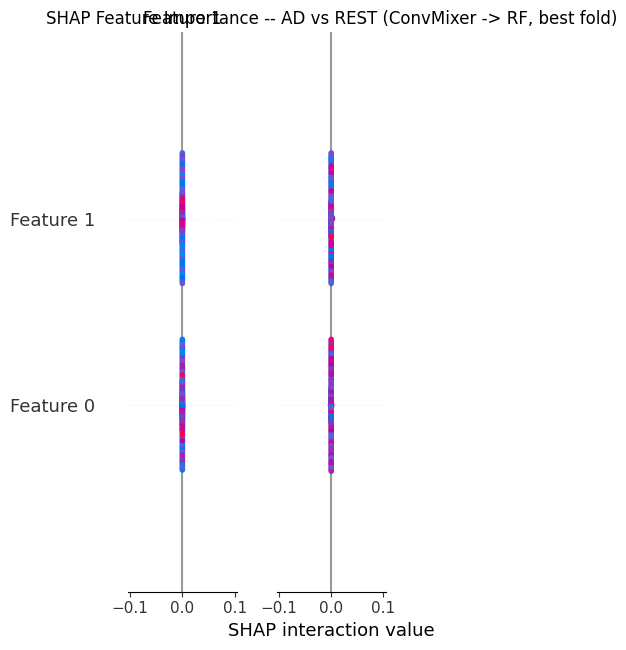

/tmp/ipykernel_58/2082141664.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[sample_idx], class_names=['REST', pos_name],
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

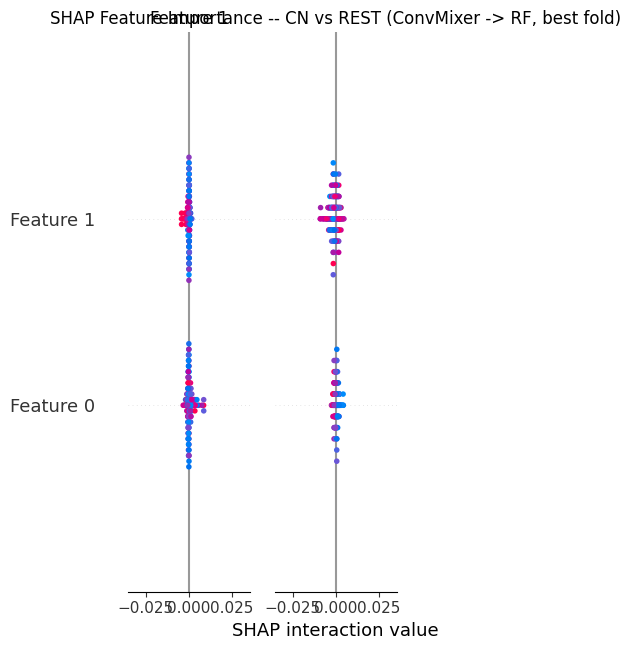

/tmp/ipykernel_58/2082141664.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[sample_idx], class_names=['REST', pos_name],
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

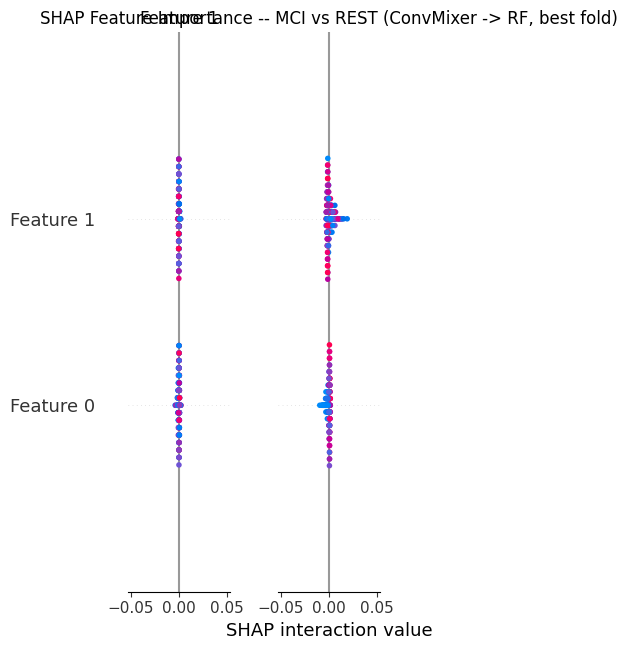

In [21]:
print('\n' + '='*60)
print('1. SHAP Analysis (Explaining the Random Forest)')
print('='*60)
print("Using the highest-weight fold's RF per class (averaging TreeExplainer")
print('output across 5 independently-trained RFs is not standard practice).')

for pos_name in CLASS_NAMES:
    fold_weights = np.array(final_results[pos_name]['fold_weights'])
    best_idx = int(np.argmax(fold_weights))
    best_model = all_fold_models[pos_name][best_idx].to(device).eval()
    best_rf    = all_fold_rfs[pos_name][best_idx]

    test_bin    = [(p, 1 if l == CLASS_NAMES.index(pos_name) else 0, pid) for p, l, pid in test_entries]
    test_loader = DataLoader(SliceDataset(test_bin, augment=False), batch_size=BATCH_SIZE, shuffle=False)
    X_test, y_test, _ = extract_features(best_model, test_loader)

    sample_idx = np.random.choice(X_test.shape[0], min(200, X_test.shape[0]), replace=False)
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test[sample_idx])

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test[sample_idx], class_names=['REST', pos_name],
                      plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance -- {pos_name} vs REST (ConvMixer -> RF, best fold)')
    plt.tight_layout()
    plt.savefig(f'{XAI_DIR}/shap_{pos_name}.png', dpi=150)
    plt.show()

    best_model.to('cpu')
    torch.cuda.empty_cache()


2. Grad-CAM (Explaining the ConvMixer, ensemble-weighted)


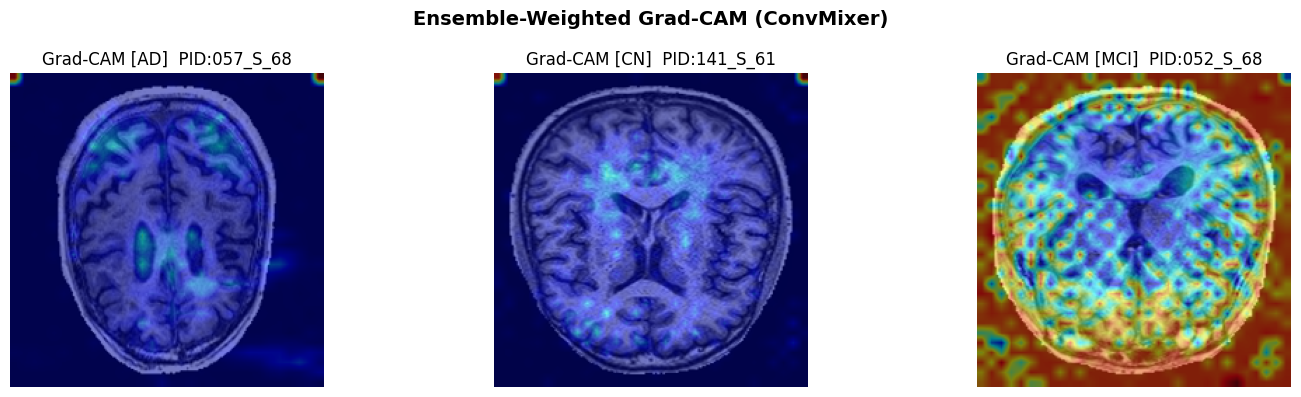

In [22]:
print('\n' + '='*60)
print('2. Grad-CAM (Explaining the ConvMixer, ensemble-weighted)')
print('='*60)

fig, axes = plt.subplots(1, len(xai_samples), figsize=(5*len(xai_samples), 4))
if len(xai_samples) == 1:
    axes = [axes]

for ax, (cls, (img_tensor, true_lbl, pid)) in zip(axes, xai_samples.items()):
    fold_weights = np.array(final_results[cls]['fold_weights'])
    cam_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[cls], fold_weights):
        fm.to(device).eval()
        target_layer = fm.backbone.blocks[-1]
        cam = GradCAM(model=fm, target_layers=[target_layer])
        grayscale_cam = cam(input_tensor=img_tensor.unsqueeze(0).to(device),
                            targets=[ClassifierOutputTarget(1)])
        cam_accum += w * grayscale_cam[0]
        fm.to('cpu')
    cam_accum = normalize_image(cam_accum)

    img_array = convert_to_rgb(normalize_image(img_tensor.cpu().numpy()))
    overlay   = create_colormap_overlay(cam_accum, img_array, alpha=0.5)
    ax.imshow(overlay); ax.set_title(f'Grad-CAM [{cls}]  PID:{pid[:8]}'); ax.axis('off')

plt.suptitle('Ensemble-Weighted Grad-CAM (ConvMixer)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{XAI_DIR}/gradcam_ensemble.png', dpi=150)
plt.show()


3. Occlusion Sensitivity (Explaining the ConvMixer, ensemble-weighted)


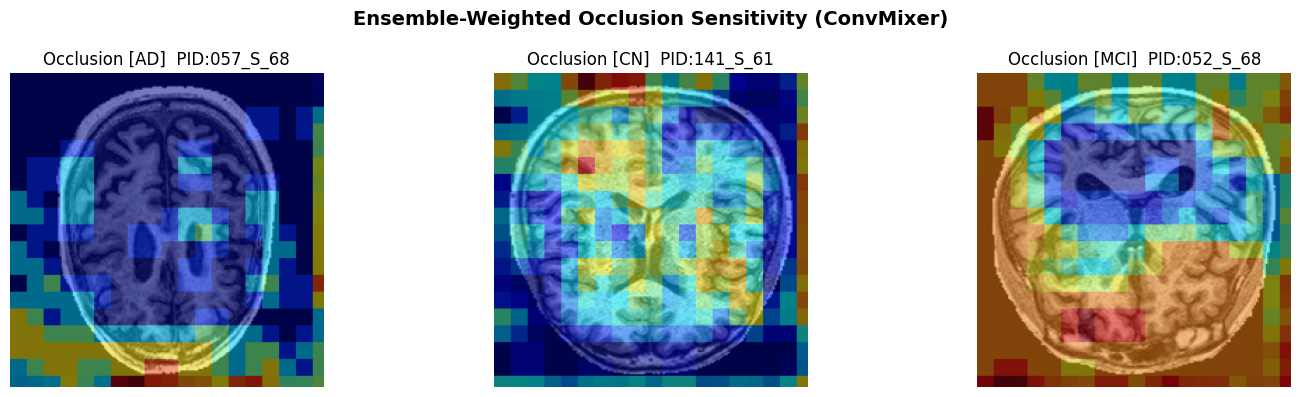

In [23]:
print('\n' + '='*60)
print('3. Occlusion Sensitivity (Explaining the ConvMixer, ensemble-weighted)')
print('='*60)

@torch.no_grad()
def occlusion_sensitivity(model, image_tensor, target_class, patch_size=24, stride=12, occlusion_value=0.0):
    model.eval()
    x = image_tensor.unsqueeze(0).to(device).clone()
    _, _, H, W = x.shape
    base_prob = torch.softmax(model(x), dim=1)[0, target_class].item()
    heat = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H, stride):
        for xx in range(0, W, stride):
            y0, y1 = y, min(y + patch_size, H)
            x0, x1 = xx, min(xx + patch_size, W)
            occ = x.clone(); occ[:, :, y0:y1, x0:x1] = occlusion_value
            p = torch.softmax(model(occ), dim=1)[0, target_class].item()
            heat[y0:y1, x0:x1] += (base_prob - p)
            counts[y0:y1, x0:x1] += 1.0
    return heat / np.maximum(counts, 1.0), base_prob

fig, axes = plt.subplots(1, len(xai_samples), figsize=(5*len(xai_samples), 4))
if len(xai_samples) == 1:
    axes = [axes]

for ax, (cls, (img_tensor, true_lbl, pid)) in zip(axes, xai_samples.items()):
    fold_weights = np.array(final_results[cls]['fold_weights'])
    heat_accum = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for fm, w in zip(all_fold_models[cls], fold_weights):
        fm.to(device).eval()
        heat, _ = occlusion_sensitivity(fm, img_tensor, target_class=1, patch_size=24, stride=12)
        heat_accum += w * heat
        fm.to('cpu')

    img_array = convert_to_rgb(normalize_image(img_tensor.cpu().numpy()))
    overlay   = create_colormap_overlay(heat_accum, img_array, alpha=0.5)
    ax.imshow(overlay); ax.set_title(f'Occlusion [{cls}]  PID:{pid[:8]}'); ax.axis('off')

plt.suptitle('Ensemble-Weighted Occlusion Sensitivity (ConvMixer)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{XAI_DIR}/occlusion_ensemble.png', dpi=150)
plt.show()

In [24]:
import os
import shutil
from IPython.display import FileLink, display

WORKING_DIR = '/kaggle/working'
ZIP_NAME    = '/kaggle/working/all_outputs'

def _zip_filter(dirpath, filenames):
    return [f for f in filenames if f.endswith('.zip')]

shutil.make_archive(
    base_name=ZIP_NAME,
    format='zip',
    root_dir=WORKING_DIR
)

zip_path = ZIP_NAME + '.zip'
size_mb  = os.path.getsize(zip_path) / 1e6
print(f'Zipped -> {zip_path}  ({size_mb:.1f} MB)')

display(FileLink(zip_path))

Zipped -> /kaggle/working/all_outputs.zip  (4266.7 MB)


/kaggle/working/all_outputs.zip